# The M5 Forecasting Engine

* **Domain:** Enterprise Supply Chain & Heavy Infrastructure
* **Objective:** ___.
* **Architecture Paradigm:** ___.

### THE MASTER BLUEPRINT


---

In [1]:
# ==============================================================================
# CELL 1: ARCHITECTURE SETUP & CONFIGURATION
# ==============================================================================
# --- 1. CORE IMPORTS ---
from __future__ import annotations
import os
import shutil
import zipfile
import gc
import subprocess
from pathlib import Path
import warnings
import random

warnings.filterwarnings("ignore")


# --- 2. Centralized Configuration (Single Source of Truth) ---
class Config:
    """
    Immutable configuration parameters for the pipeline.
    """
    # Reproducibility
    SEED: int = 75

    # Path Management
    BASE_DIR: Path = Path.cwd().parent
    DATA_DIR: Path = BASE_DIR / "data" / "m5"
    TRAIN_FILE: Path = "sales_train_validation.csv"
    CALENDAR_FILE: Path = "calendar.csv"
    PRICES_FILE: Path = "sell_prices.csv"

    # Optimization Constants
    N_FOLDS = 5
    # Default target for M5 is predicting the sales volume
    TARGET_COL: str = "sales"


# --- 3. Deterministic Environment Lock ---
os.environ["PYTHONHASHSEED"] = str(Config.SEED)
random.seed(Config.SEED)

# --- 4. Data ---
import numpy as np

np.random.seed(Config.SEED)

# External Frameworks & Display Engines
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display & Plot Configuration
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams.update(
        {"figure.figsize": (12, 5), "figure.dpi": 100, 'figure.max_open_warning': 0, "font.size": 11, "axes.grid": True,
                "grid.alpha": 0.3, "axes.titlesize": 13, "axes.labelsize": 11, "axes.unicode_minus": False, })
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)

print("[*] Core Library Imported Successfully. Environment Configured.")

[*] Core Library Imported Successfully. Environment Configured.


In [2]:
# =============================================================================
# CELL 2: KAGGLE AUTHENTICATION, DOWNLOAD, AND MEM-OPT INGESTION
# =============================================================================

# Use the API directly instead of subprocess
from kaggle.api.kaggle_api_extended import KaggleApi

def setup_kaggle_credentials():
    """
    Locates kaggle.json in the current working directory and safely
    copies it to the WSL/Linux home directory with strict 0o600 permissions.
    """
    print("--- Setting up Kaggle Credentials ---")
    current_dir_key = Path("kaggle.json")
    home_dir_kaggle = Path.home() / ".kaggle"
    dest_key = home_dir_kaggle / "kaggle.json"

    # Create ~/.kaggle directory if it doesn't exist
    if not home_dir_kaggle.exists():
        home_dir_kaggle.mkdir(parents=True)
        print(f"[*] Created directory: {home_dir_kaggle}")

    # Copy the key and set strict permissions
    if current_dir_key.exists():
        shutil.copy(current_dir_key, dest_key)
        os.chmod(dest_key, 0o600)
        print(f"[*] Copied kaggle.json to {dest_key} and set permissions to 600.")
    elif dest_key.exists():
        print(f"[*] kaggle.json already exists in {dest_key}. Proceeding.")
    else:
        raise FileNotFoundError(
            f"Could not find 'kaggle.json' in the current directory ({Path.cwd()}) "
            f"or in {home_dir_kaggle}. Please place it in the project root."
        )

def fetch_m5_data_via_api(download_path: Path):
    """
    Authenticates with Kaggle API and downloads the M5 competition dataset.
    """
    setup_kaggle_credentials()

    print("\n--- Authenticating with Kaggle ---")
    api = KaggleApi()
    api.authenticate()
    print("[*] Authentication Successful!")

    if not download_path.exists():
        download_path.mkdir(parents=True, exist_ok=True)

    competition_name = "m5-forecasting-accuracy"
    expected_file = download_path / "sales_train_validation.csv"

    if expected_file.exists():
        print("[*] M5 Data already exists in target directory. Skipping download.")
        return

    print(f"\n--- Downloading M5 Competition Data ---")
    print(f"[*] Downloading to: {download_path} ... This may take a few minutes.")

    # Download the entire competition bundle
    api.competition_download_files(competition_name, path=str(download_path))

    zip_path = download_path / f"{competition_name}.zip"
    if zip_path.exists():
        print(f"[*] Extracting {zip_path.name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(download_path)
        zip_path.unlink() # Cleanup zip
        print("[*] Extraction complete and zip removed.")
    else:
        print("[!] Warning: Expected zip file not found after download.")

# === MEM-OPT ===

def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    Iterates through all columns of a dataframe and modifies the data type
    to reduce memory usage safely based on min/max values.
    """
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtypes

        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"Memory decreased from {start_mem:.2f} MB to {end_mem:.2f} MB ({(100 * (start_mem - end_mem) / start_mem):.1f}% reduction)")

    return df

In [3]:
# =============================================================================
# CELL 3: INGESTION AND UNPIVOT (POC MODE: SINGLE STORE)
# =============================================================================

def process_m5_ingestion_poc(data_dir: Path, target_store: str = 'CA_1') -> pd.DataFrame:
    """
    Loads raw M5 data, filters to a SINGLE STORE for rapid POC iteration,
    converts to long-format, and applies downcasting.
    """
    sales_file_path = data_dir / 'sales_train_validation.csv'

    if not sales_file_path.exists():
        raise FileNotFoundError(f"Sales dataset not found at {sales_file_path}.")

    print(f"\n--- Processing M5 Data (POC Mode: Store {target_store}) ---")
    print("1. Loading raw wide-format sales data...")
    df_wide = pd.read_csv(sales_file_path)

    print(f"2. Filtering to target store: {target_store}...")
    df_wide = df_wide[df_wide['store_id'] == target_store].copy()

    print("3. Downcasting wide dataframe before melting...")
    df_wide = reduce_mem_usage(df_wide)

    print("4. Unpivoting (Melting) to transactional long-format...")
    id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

    df_long = pd.melt(
        df_wide,
        id_vars=id_vars,
        var_name='d',
        value_name='sales'
    )

    del df_wide
    gc.collect()

    print("5. Downcasting long dataframe...")
    df_long = reduce_mem_usage(df_long)

    return df_long
# =============================================================================
# EXECUTION PIPELINE
# =============================================================================
# Assuming Config is already defined in Cell 1
Config.DATA_DIR.mkdir(parents=True, exist_ok=True)

# 1. Fetch
fetch_m5_data_via_api(Config.DATA_DIR)

# 2. Process
df_sales_long = process_m5_ingestion_poc(Config.DATA_DIR)

print("\n[*] Cell Execution Complete. Ingestion pipeline ready.")

--- Setting up Kaggle Credentials ---
[*] kaggle.json already exists in /home/nadavgordonbar/.kaggle/kaggle.json. Proceeding.

--- Authenticating with Kaggle ---
[*] Authentication Successful!
[*] M5 Data already exists in target directory. Skipping download.

--- Processing M5 Data (POC Mode: Store CA_1) ---
1. Loading raw wide-format sales data...
2. Filtering to target store: CA_1...
3. Downcasting wide dataframe before melting...
Memory decreased from 44.66 MB to 6.52 MB (85.4% reduction)
4. Unpivoting (Melting) to transactional long-format...
5. Downcasting long dataframe...
Memory decreased from 322.63 MB to 322.63 MB (0.0% reduction)

[*] Cell Execution Complete. Ingestion pipeline ready.


In [4]:
# =============================================================================
# CELL 4: DENORMALIZATION & CONTEXTUAL ENVELOPE (GATE 2)
# =============================================================================

def apply_contextual_envelope(df_long: pd.DataFrame, data_dir: Path) -> pd.DataFrame:
    """
    Merges external dimensions (Calendar events and Pricing data) into the
    main transaction log while maintaining strict memory constraints.
    """
    print("\n--- Applying Contextual Envelope (Denormalization) ---")

    # ---------------------------------------------------------
    # 1. Process and Join Calendar
    # ---------------------------------------------------------
    calendar_path = data_dir / Config.CALENDAR_FILE
    print(f"[*] Loading Calendar dimension from: {calendar_path.name}")
    calendar = pd.read_csv(calendar_path)

    # Keep only features relevant to macroeconomic shocks/time mapping
    cols_to_keep_cal = ['d', 'wm_yr_wk', 'event_name_1', 'event_type_1',
                        'snap_CA', 'snap_TX', 'snap_WI']
    calendar = calendar[cols_to_keep_cal]

    # Fill missing events with a neutral string, then optimize memory
    calendar['event_name_1'] = calendar['event_name_1'].fillna('NoEvent')
    calendar['event_type_1'] = calendar['event_type_1'].fillna('NoEvent')
    calendar = reduce_mem_usage(calendar, verbose=False)

    print("[*] Merging Calendar to Transaction Log...")
    df_long = df_long.merge(calendar, on='d', how='left')

    del calendar
    gc.collect()

    # ---------------------------------------------------------
    # 2. Process and Join Prices
    # ---------------------------------------------------------
    prices_path = data_dir / Config.PRICES_FILE
    print(f"[*] Loading Pricing dimension from: {prices_path.name}")
    prices = pd.read_csv(prices_path)
    prices = reduce_mem_usage(prices, verbose=False)

    print("[*] Merging Prices to Transaction Log...")
    # Prices vary by store, item, and week
    df_long = df_long.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

    del prices
    gc.collect()

    print("[*] Final Memory Optimization Sweep...")
    df_long = reduce_mem_usage(df_long)

    print(f"[*] Denormalization Complete. Final Matrix Shape: {df_long.shape}")
    return df_long

# Execute the Denormalization
df_sales_long = apply_contextual_envelope(df_sales_long, Config.DATA_DIR)


--- Applying Contextual Envelope (Denormalization) ---
[*] Loading Calendar dimension from: calendar.csv
[*] Merging Calendar to Transaction Log...
[*] Loading Pricing dimension from: sell_prices.csv
[*] Merging Prices to Transaction Log...
[*] Final Memory Optimization Sweep...
Memory decreased from 450.57 MB to 450.57 MB (0.0% reduction)
[*] Denormalization Complete. Final Matrix Shape: (5832737, 15)


In [5]:
# =============================================================================
# CELL 5: THE LONGITUDINAL FIREWALL (FEATURE ENGINEERING)
# =============================================================================

def engineer_longitudinal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Safely generates historical lag and rolling window features while
    strictly preventing look-ahead bias (Target Leakage).
    """
    print("\n--- Initiating Longitudinal Firewall (Feature Engineering) ---")

    # 1. Temporal Integer Extraction (Critical for sorting)
    print("1. Extracting strict temporal integer to prevent lexical sort errors...")
    # Converts 'd_145' -> 145
    df['d_int'] = df['d'].str.replace('d_', '').astype(np.int16)

    # 2. Chronological Ordering
    print("2. Enforcing absolute chronological order...")
    df = df.sort_values(['store_id', 'item_id', 'd_int']).reset_index(drop=True)

    # 3. Base Shift Operations (Lags)
    # We group by item to prevent shifting sales from item A to item B
    print("3. Generating Lagged signals (t-7, t-28)...")
    grouped = df.groupby(['store_id', 'item_id'])['sales']

    # Lag 7: What were the sales exactly a week ago?
    df['lag_7'] = grouped.shift(7).astype(np.float16)
    # Lag 28: What were the sales exactly 4 weeks ago?
    df['lag_28'] = grouped.shift(28).astype(np.float16)

    # 4. Rolling Window Operations (Momentum)
    # MUST apply shift() before rolling() to avoid target leakage!
    print("4. Generating Rolling Momentum metrics (strictly on shifted data)...")

    # Average sales over the week ending 7 days ago
    df['rmean_7_7'] = grouped.transform(
        lambda x: x.shift(7).rolling(window=7).mean()
    ).astype(np.float16)

    # Average sales over the week ending 28 days ago
    df['rmean_28_7'] = grouped.transform(
        lambda x: x.shift(28).rolling(window=7).mean()
    ).astype(np.float16)

    # 5. Final memory optimization
    print("5. Downcasting engineered features...")
    df = reduce_mem_usage(df, verbose=False)

    print(f"[*] Feature Engineering Complete. New Matrix Shape: {df.shape}")
    return df

# Execute the Feature Engineering
df_sales_long = engineer_longitudinal_features(df_sales_long)

# Preview the integrity of our firewall
print("\n[*] Validating Firewall (Previewing an item's chronological sequence):")
preview_cols = ['item_id', 'd_int', 'sales', 'lag_7', 'rmean_7_7']
display(df_sales_long[preview_cols].head(15))


--- Initiating Longitudinal Firewall (Feature Engineering) ---
1. Extracting strict temporal integer to prevent lexical sort errors...
2. Enforcing absolute chronological order...
3. Generating Lagged signals (t-7, t-28)...
4. Generating Rolling Momentum metrics (strictly on shifted data)...
5. Downcasting engineered features...
[*] Feature Engineering Complete. New Matrix Shape: (5832737, 20)

[*] Validating Firewall (Previewing an item's chronological sequence):


,item_id,d_int,sales,lag_7,rmean_7_7
0,FOODS_1_001,1,3,NaN,NaN
1,FOODS_1_001,2,0,NaN,NaN
2,FOODS_1_001,3,0,NaN,NaN
3,FOODS_1_001,4,1,NaN,NaN
4,FOODS_1_001,5,4,NaN,NaN
5,FOODS_1_001,6,2,NaN,NaN
6,FOODS_1_001,7,0,NaN,NaN
7,FOODS_1_001,8,2,3.0000,NaN
8,FOODS_1_001,9,0,0.0000,NaN
9,FOODS_1_001,10,0,0.0000,NaN



--- Visualizing Physics for Item: HOBBIES_1_004 ---


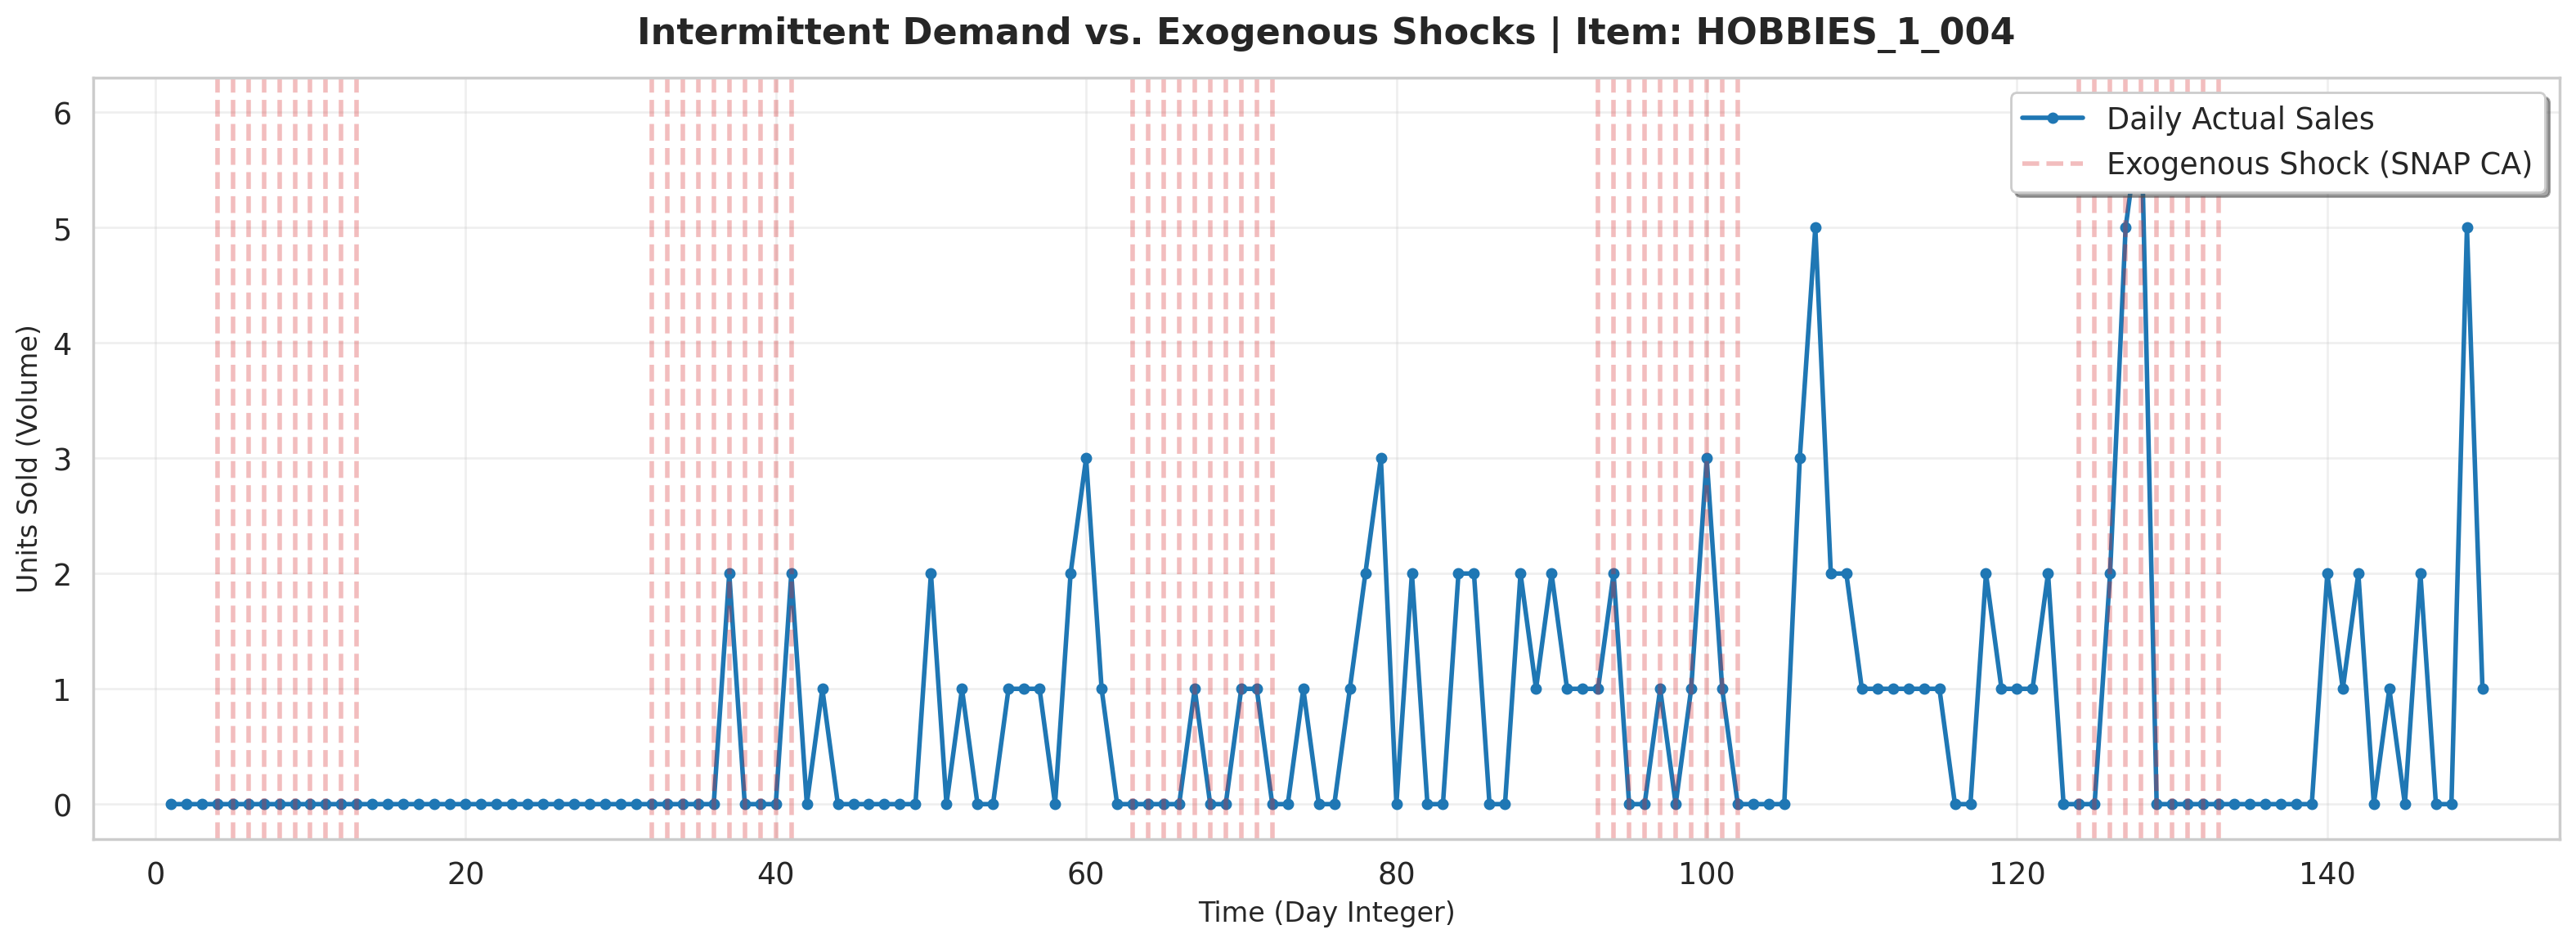

In [6]:
# =============================================================================
# CELL 6: VISUAL EDA - THE PHYSICS OF INTERMITTENT DEMAND (GATE 4)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_exogenous_shocks(df: pd.DataFrame, target_item: str, days_to_show: int = 200):
    """
    Visualizes the raw intermittent demand of a single product and overlays
    external macroeconomic shocks (e.g., SNAP days) to prove causality.
    """
    print(f"\n--- Visualizing Physics for Item: {target_item} ---")

    # Isolate a single item and take a temporal slice
    item_data = df[df['item_id'] == target_item].copy()
    item_data = item_data.sort_values('d_int').head(days_to_show)

    if item_data.empty:
        print(f"[!] No data found for {target_item}.")
        return

    # Setup the canvas
    plt.figure(figsize=(16, 6))
    sns.set_style("whitegrid")

    # 1. Plot the raw demand (The "Heartbeat")
    plt.plot(
        item_data['d_int'],
        item_data['sales'],
        color='#1f77b4',
        linewidth=2,
        marker='o',
        markersize=4,
        label='Daily Actual Sales'
    )

    # 2. Overlay the Exogenous Shocks (SNAP Days)
    snap_days = item_data[item_data['snap_CA'] == 1]['d_int']

    # Draw vertical lines for shocks
    for sd in snap_days:
        plt.axvline(x=sd, color='#d62728', alpha=0.3, linestyle='--', linewidth=2)

    # Add a dummy line for the legend
    plt.axvline(x=-100, color='#d62728', alpha=0.3, linestyle='--', linewidth=2, label='Exogenous Shock (SNAP CA)')

    # 3. Aesthetics & Business Context
    plt.title(f"Intermittent Demand vs. Exogenous Shocks | Item: {target_item}", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Time (Day Integer)", fontsize=12)
    plt.ylabel("Units Sold (Volume)", fontsize=12)
    plt.xlim(item_data['d_int'].min() - 5, item_data['d_int'].max() + 5)
    plt.legend(loc='upper right', frameon=True, shadow=True)
    plt.tight_layout()

    # Display the physical evidence
    plt.show()

# Execute the Visualization
# We pick a specific HOBBIES item known to have intermittent, spikey behavior
target_sku = 'HOBBIES_1_004'
plot_exogenous_shocks(df_sales_long, target_item=target_sku, days_to_show=150)

In [7]:
# =============================================================================
# CELL 7: FEATURE ENRICHMENT & TIME-SERIES SPLIT (UPDATED)
# =============================================================================
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

def prepare_benchmark_data(df: pd.DataFrame):
    print("--- 1. Feature Enrichment & Schema Enforcement ---")

    # 1. Temporal dimensions (Cyclicality)
    df['day_of_week'] = (df['d_int'] % 7).astype(np.int8)

    # 2. Exogenous Interaction Term: Is it a SNAP day AND a weekend?
    df['is_weekend'] = df['day_of_week'].isin([1, 2]).astype(np.int8)
    df['snap_weekend'] = (df['snap_CA'] * df['is_weekend']).astype(np.int8)

    # 3. SCHEMA ENFORCEMENT: Convert all 'object' (strings) to 'category' for LightGBM
    for col in df.columns:
        if df[col].dtype == 'object':
            print(f"[*] Coercing object column to category: {col}")
            df[col] = df[col].astype('category')

    # Drop rows with NaNs caused by the Lags (Look-back window is 28 days)
    df_clean = df.dropna().copy()

    print("\n--- 2. Time-Series Split (Chronological) ---")

    max_day = df_clean['d_int'].max()
    split_day = max_day - 30

    train_mask = df_clean['d_int'] <= split_day
    val_mask = df_clean['d_int'] > split_day

    df_train = df_clean[train_mask]
    df_val = df_clean[val_mask]

    print(f"Train Shape: {df_train.shape} | Time range: {df_train['d_int'].min()} to {df_train['d_int'].max()}")
    print(f"Val Shape:   {df_val.shape}  | Time range: {df_val['d_int'].min()} to {df_val['d_int'].max()}")

    # Define features
    exclude_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales']
    features = [c for c in df_clean.columns if c not in exclude_cols]

    X_train, y_train = df_train[features], df_train['sales']
    X_val, y_val = df_val[features], df_val['sales']

    return X_train, y_train, X_val, y_val, df_val, features

X_train, y_train, X_val, y_val, df_val_full, features = prepare_benchmark_data(df_sales_long)

--- 1. Feature Enrichment & Schema Enforcement ---
[*] Coercing object column to category: id
[*] Coercing object column to category: item_id
[*] Coercing object column to category: dept_id
[*] Coercing object column to category: cat_id
[*] Coercing object column to category: store_id
[*] Coercing object column to category: state_id
[*] Coercing object column to category: d
[*] Coercing object column to category: event_name_1
[*] Coercing object column to category: event_type_1

--- 2. Time-Series Split (Chronological) ---
Train Shape: (4566029, 23) | Time range: 35 to 1883
Val Shape:   (91470, 23)  | Time range: 1884 to 1913


In [8]:
# =============================================================================
# CELL 8: THE LIGHTGBM LOSS BENCHMARK
# =============================================================================

print("\\n--- Training Model A: Standard RMSE Objective ---")
lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

params_rmse = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'seed': 75
}

model_rmse = lgb.train(
    params_rmse,
    lgb_train,
    num_boost_round=300,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

print("\\n--- Training Model B: Zero-Inflated Tweedie Objective ---")
params_tweedie = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.1, # 1.0 = Poisson, 2.0 = Gamma. 1.1-1.5 is standard for zero-inflated demand.
    'metric': 'rmse', # We evaluate on RMSE to compare fairly, but optimize on Tweedie
    'learning_rate': 0.05,
    'num_leaves': 31,
    'verbose': -1,
    'seed': 75
}

model_tweedie = lgb.train(
    params_tweedie,
    lgb_train,
    num_boost_round=300,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
)

# --- Benchmark Evaluation ---
df_val_full['pred_rmse'] = model_rmse.predict(X_val)
df_val_full['pred_tweedie'] = model_tweedie.predict(X_val)

# Clip negative predictions (physical items cannot be negatively sold)
df_val_full['pred_rmse'] = df_val_full['pred_rmse'].clip(0)
df_val_full['pred_tweedie'] = df_val_full['pred_tweedie'].clip(0)

# We will visualize this on the specific SKU we examined in Gate 4
target_sku = 'HOBBIES_1_004'
sku_val = df_val_full[df_val_full['item_id'] == target_sku].sort_values('d_int')

print(f"\\n[*] Benchmark complete. Ready to plot results for {target_sku}.")

\n--- Training Model A: Standard RMSE Objective ---
\n--- Training Model B: Zero-Inflated Tweedie Objective ---
\n[*] Benchmark complete. Ready to plot results for HOBBIES_1_004.


[*] Hunting for the perfect intermittent SKU in the validation set...
[*] Success! Found FOODS_1_015 (Has 17 days of ZERO demand out of 30).

--- Visualizing Benchmark for Item: FOODS_1_015 ---


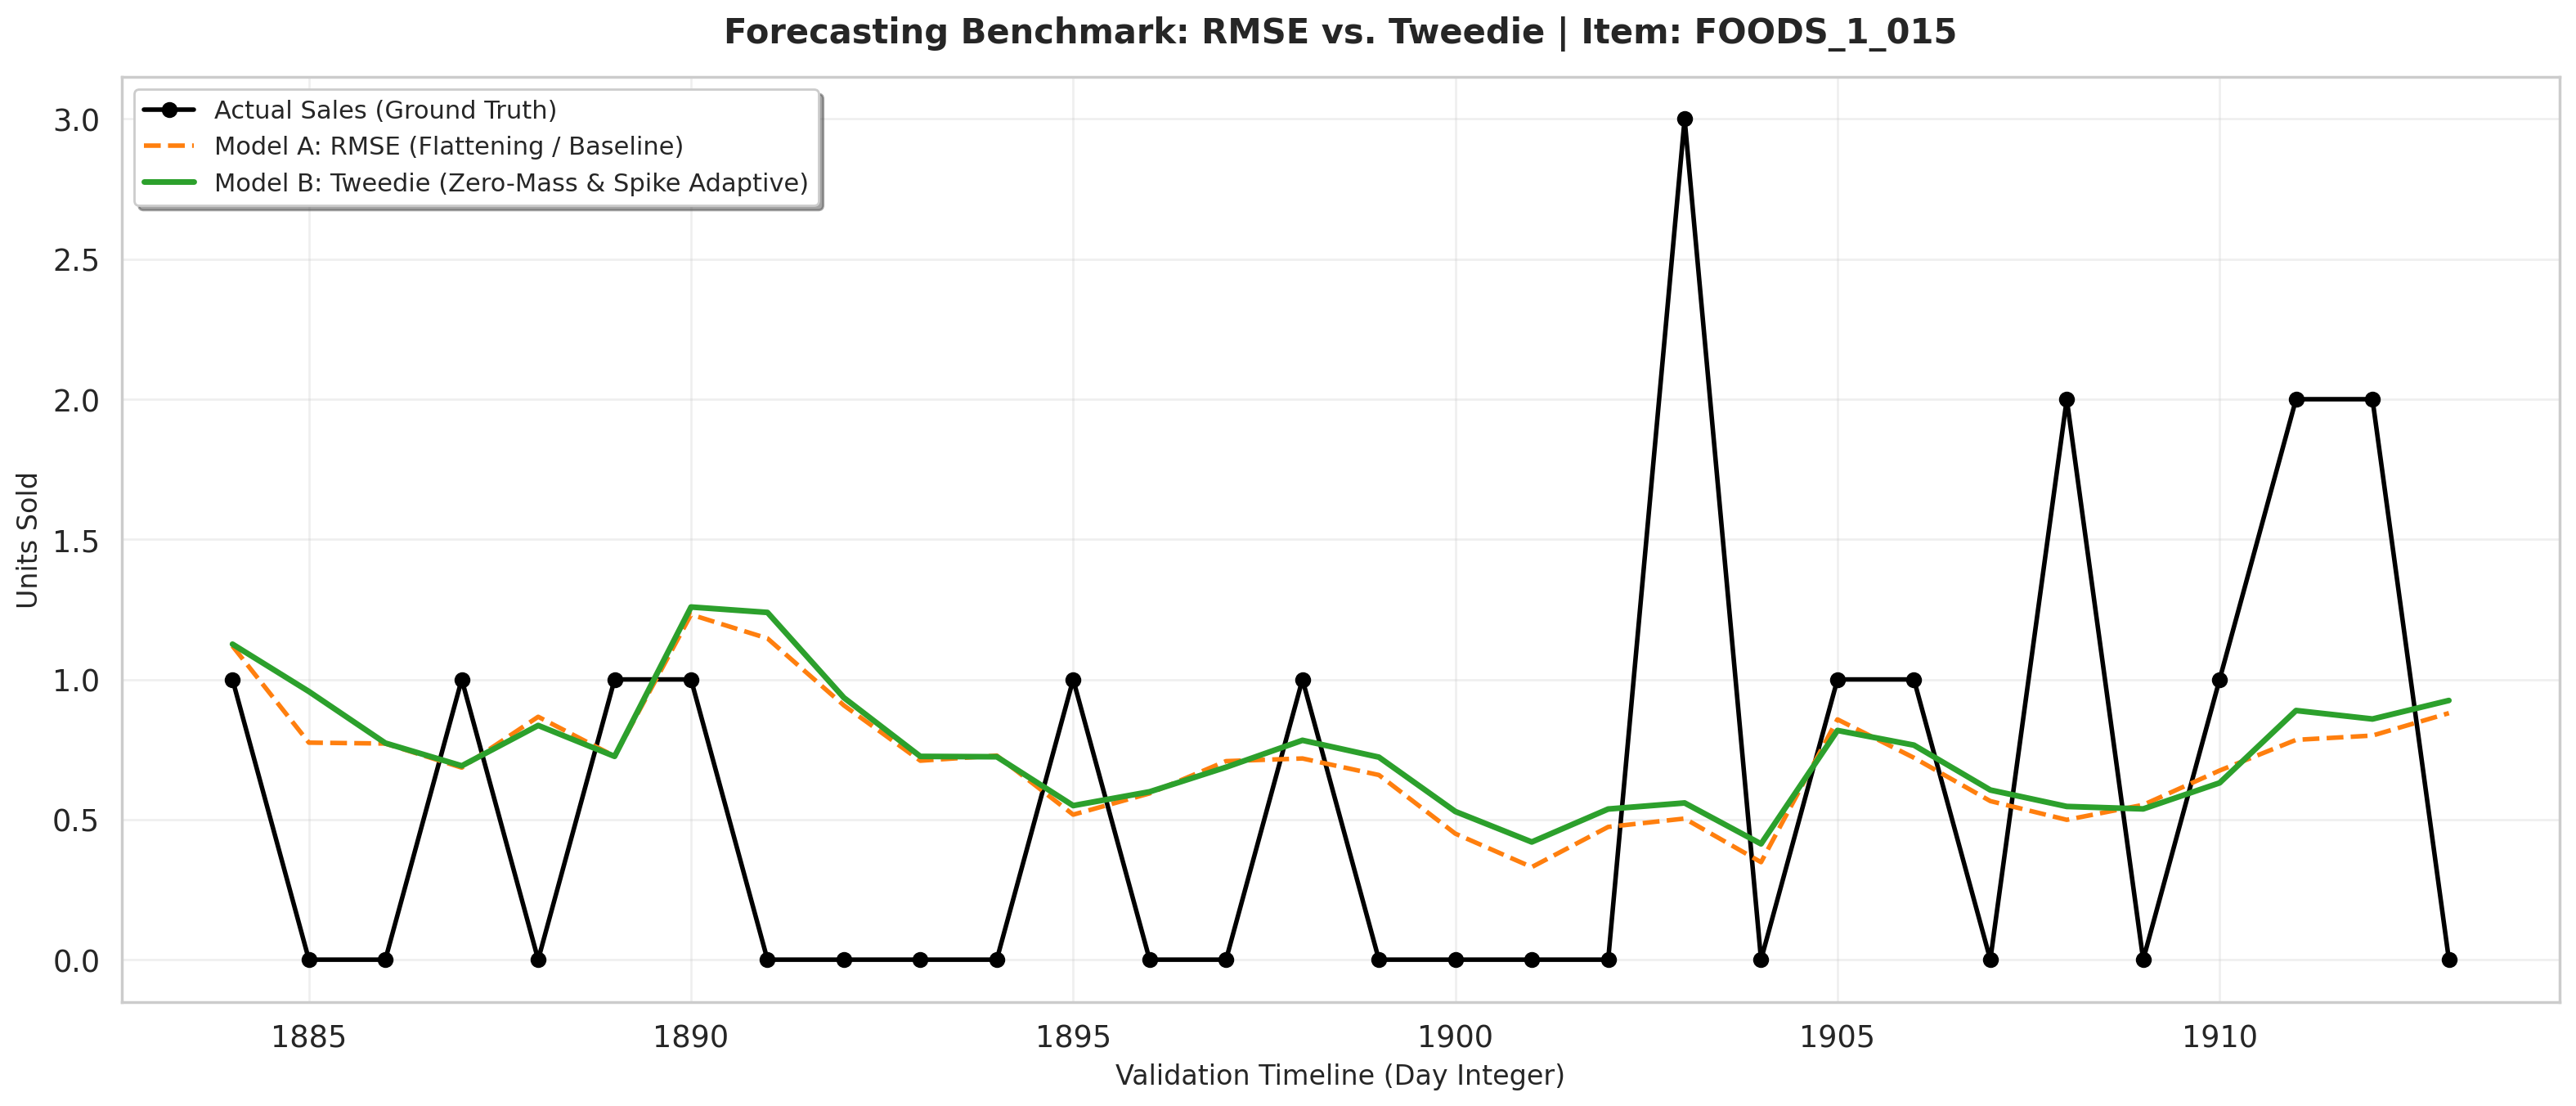

In [11]:
# =============================================================================
# CELL 9: VISUALIZING THE LOSS FUNCTION BENCHMARK (DYNAMIC SKU)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def plot_benchmark_results(df_val: pd.DataFrame, target_item: str):
    """
    Plots the predictions of RMSE vs Tweedie against the ground truth actuals.
    Proves that RMSE flattens the signal while Tweedie captures the physical spikes.
    """
    print(f"\n--- Visualizing Benchmark for Item: {target_item} ---")

    item_val = df_val[df_val['item_id'] == target_item].copy()
    item_val = item_val.sort_values('d_int')

    if item_val.empty:
        print(f"[!] No validation data found for {target_item}.")
        return

    plt.figure(figsize=(16, 7))
    sns.set_style("whitegrid")

    # 1. Ground Truth (Actual Sales)
    plt.plot(
        item_val['d_int'], item_val['sales'],
        color='black', linewidth=2, marker='o', markersize=6,
        label='Actual Sales (Ground Truth)'
    )

    # 2. Model A: RMSE (The "Averager")
    plt.plot(
        item_val['d_int'], item_val['pred_rmse'],
        color='#ff7f0e', linewidth=2, linestyle='--',
        label='Model A: RMSE (Flattening / Baseline)'
    )

    # 3. Model B: Tweedie (The "Spike Hunter")
    plt.plot(
        item_val['d_int'], item_val['pred_tweedie'],
        color='#2ca02c', linewidth=2.5,
        label='Model B: Tweedie (Zero-Mass & Spike Adaptive)'
    )

    plt.title(f"Forecasting Benchmark: RMSE vs. Tweedie | Item: {target_item}", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Validation Timeline (Day Integer)", fontsize=12)
    plt.ylabel("Units Sold", fontsize=12)
    plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
    plt.tight_layout()
    plt.show()

# --- DYNAMIC SKU SELECTOR ---
print("[*] Hunting for the perfect intermittent SKU in the validation set...")

# We calculate total sales and number of "zero demand" days for each item in the validation set
item_stats = df_val_full.groupby('item_id').agg(
    total_sales=('sales', 'sum'),
    zero_days=('sales', lambda x: (x == 0).sum())
)

# Rule: Must have sold at least 15 units total, but sit at ZERO sales for at least 15 days out of 30.
intermittent_items = item_stats[(item_stats['total_sales'] > 15) & (item_stats['zero_days'] >= 15)]

if not intermittent_items.empty:
    # Pick the top result
    target_sku = intermittent_items.index[0]
    zero_count = intermittent_items.loc[target_sku, 'zero_days']
    print(f"[*] Success! Found {target_sku} (Has {zero_count} days of ZERO demand out of 30).")
    plot_benchmark_results(df_val_full, target_sku)
else:
    print("[!] Could not find an ideal intermittent item. Falling back to the first available item.")
    target_sku = df_val_full['item_id'].unique()[0]
    plot_benchmark_results(df_val_full, target_sku)

# The Engineering Debugger: Looking at the raw array instead of the plot
target_sku = intermittent_items.index[0] # Using the dynamic item we found
item_val = df_val_full[df_val_full['item_id'] == target_sku].sort_values('d_int')

# Print the days where ACTUAL sales were greater than 0, to see how the models reacted
print(item_val[item_val['sales'] > 0][['d_int', 'sales', 'pred_rmse', 'pred_tweedie']].head(10))